<a href="https://colab.research.google.com/github/ushi-masuka/ml-practice-and-experimentation/blob/main/kaggle_loan_payback_playground.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
test=pd.read_csv('/content/test.csv')
train=pd.read_csv('/content/train.csv')
test

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade
0,593994,28781.05,0.049,626,11461.42,14.73,Female,Single,High School,Employed,Other,D5
1,593995,46626.39,0.093,732,15492.25,12.85,Female,Married,Master's,Employed,Other,C1
2,593996,54954.89,0.367,611,3796.41,13.29,Male,Single,Bachelor's,Employed,Debt consolidation,D1
3,593997,25644.63,0.110,671,6574.30,9.57,Female,Single,Bachelor's,Employed,Debt consolidation,C3
4,593998,25169.64,0.081,688,17696.89,12.80,Female,Married,PhD,Employed,Business,C1
...,...,...,...,...,...,...,...,...,...,...,...,...
254564,848558,92835.97,0.068,744,29704.00,13.48,Female,Single,Bachelor's,Employed,Debt consolidation,B2
254565,848559,48846.47,0.091,634,20284.33,9.58,Female,Married,High School,Employed,Debt consolidation,D4
254566,848560,20668.52,0.096,718,26387.55,9.00,Male,Single,Master's,Employed,Debt consolidation,C4
254567,848561,34105.09,0.094,739,11107.36,9.81,Male,Single,Bachelor's,Employed,Business,C2


In [3]:
train

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736.0,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636.0,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694.0,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533.0,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665.0,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
400835,400835,19349.83,0.137,663.0,6031.86,8.58,Male,Married,Bachelor's,Unemployed,Debt consolidation,D4,0.0
400836,400836,26344.01,0.076,690.0,10111.34,12.34,Female,Single,Bachelor's,Retired,Business,C2,1.0
400837,400837,81068.68,0.080,757.0,21487.59,11.79,Male,Married,Bachelor's,Employed,Other,B1,1.0
400838,400838,49005.60,0.181,548.0,10963.20,15.69,Female,Single,Bachelor's,Employed,Education,F5,0.0


In [18]:
#preprocessing
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  object 
 7   marital_status        593994 non-null  object 
 8   education_level       593994 non-null  object 
 9   employment_status     593994 non-null  object 
 10  loan_purpose          593994 non-null  object 
 11  grade_subgrade        593994 non-null  object 
 12  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 58.9+ MB


In [5]:
train['marital_status'].value_counts()

,count
marital_status,
Single,194930
Married,186881
Divorced,14513
Widowed,4515


In [8]:
train['gender'].value_counts()

,count
gender,
Female,206835
Male,191507
Other,2497


In [9]:
train['education_level'].value_counts()

,count
education_level,
Bachelor's,188928
High School,123718
Master's,62708
Other,18016
PhD,7469


In [10]:
train['employment_status'].value_counts()

,count
employment_status,
Employed,304034
Unemployed,42172
Self-employed,35626
Retired,11014
Student,7993


In [7]:
train['loan_paid_back'].value_counts()

,count
loan_paid_back,
1.0,320233
0.0,80606


In [13]:
train['loan_purpose'].value_counts()

,count
loan_purpose,
Debt consolidation,219169
Other,43022
Car,39283
Home,29693
Education,24741
Business,23830
Medical,15423
Vacation,5678


In [14]:
train['grade_subgrade'].value_counts()

,count
grade_subgrade,
C3,39292
C4,37833
C2,36633
C1,36150
C5,36003
D1,25010
D3,24742
D4,23775
D2,23214


In [23]:
train['marital_status']=train['marital_status'].astype('category')
train['gender']=train['gender'].astype('category')
train['education_level']=train['education_level'].astype('category')
train['employment_status']=train['employment_status'].astype('category')
train['loan_paid_back']=train['loan_paid_back'].astype('bool')
train['loan_purpose']=train['loan_purpose'].astype('category')
train['grade_subgrade']=train['grade_subgrade'].astype('category')

In [24]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   id                    593994 non-null  int64   
 1   annual_income         593994 non-null  float64 
 2   debt_to_income_ratio  593994 non-null  float64 
 3   credit_score          593994 non-null  int64   
 4   loan_amount           593994 non-null  float64 
 5   interest_rate         593994 non-null  float64 
 6   gender                593994 non-null  category
 7   marital_status        593994 non-null  category
 8   education_level       593994 non-null  category
 9   employment_status     593994 non-null  category
 10  loan_purpose          593994 non-null  category
 11  grade_subgrade        593994 non-null  category
 12  loan_paid_back        593994 non-null  bool    
dtypes: bool(1), category(6), float64(4), int64(2)
memory usage: 31.2 MB


In [33]:
train.columns

Index(['id', 'annual_income', 'debt_to_income_ratio', 'credit_score',
       'loan_amount', 'interest_rate', 'gender', 'marital_status',
       'education_level', 'employment_status', 'loan_purpose',
       'grade_subgrade', 'loan_paid_back'],
      dtype='object')

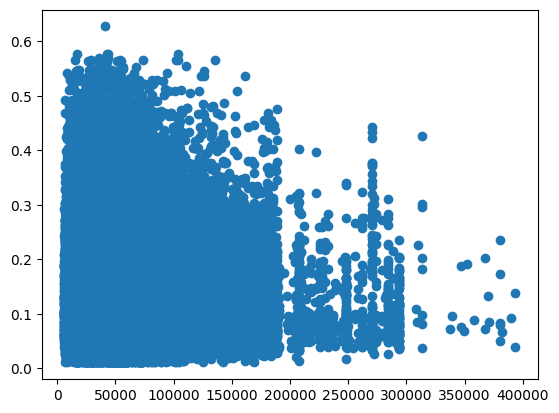

In [28]:
#eda
plt.scatter(train['annual_income'],train['debt_to_income_ratio'])


In [29]:
train.describe()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate
count,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000
mean,296996.500000,48212.202976,0.120696,680.916009,15020.297629,12.356345
std,171471.442235,26711.942078,0.068573,55.424956,6926.530568,2.008959
min,0.000000,6002.430000,0.011000,395.000000,500.090000,3.200000
25%,148498.250000,27934.400000,0.072000,646.000000,10279.620000,10.990000
50%,296996.500000,46557.680000,0.096000,682.000000,15000.220000,12.370000
75%,445494.750000,60981.320000,0.156000,719.000000,18858.580000,13.680000
max,593993.000000,393381.740000,0.627000,849.000000,48959.950000,20.990000


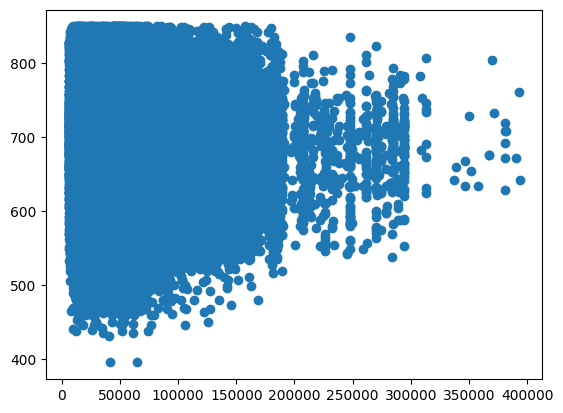

In [30]:
plt.scatter(train['annual_income'],train['credit_score'])

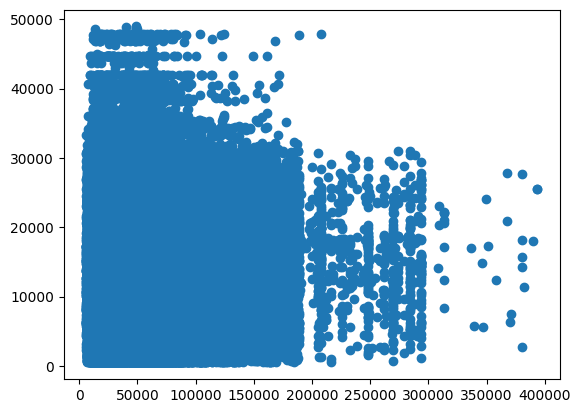

In [31]:
plt.scatter(train['annual_income'],train['loan_amount'])

In [32]:
train['loan_paid_back'].value_counts(normalize=True)

,proportion
loan_paid_back,
True,0.79882
False,0.20118


In [36]:
train.groupby('loan_paid_back')[['annual_income', 'debt_to_income_ratio', 'credit_score',
       'loan_amount', 'interest_rate']].agg(["mean",'max','min',"std"])

annual_income                                    \
                        mean        max      min           std   
loan_paid_back                                                   
False           47875.503881  393381.74  6098.80  27199.060946   
True            48296.999711  393064.03  6002.43  26587.212646   

               debt_to_income_ratio                         credit_score       \
                               mean    max    min       std         mean  max   
loan_paid_back                                                                  
False                      0.166564  0.627  0.011  0.083245   655.010628  849   
True                       0.109144  0.577  0.011  0.058975   687.440208  849   

                                 loan_amount                                 \
                min        std          mean       max     min          std   
loan_paid_back                                                                
False           395  51.680938  15072.223883  48959.95  507.42  6945.374637   
True            395  54.418255  15007.220145  48954.70  500.09  6921.722581   

               interest_rate                         
                        mean    max   min       std  
loan_paid_back                                       
False              12.881495  20.99  3.89  1.981273  
True               12.224088  20.84  3.20  1.994191

In [45]:
pd.crosstab(train['gender'],train['loan_paid_back'])

loan_paid_back,False,True
gender,,
Female,60712,245463
Male,58025,226066
Other,763,2965


In [43]:
pd.crosstab(train['gender'],train['loan_paid_back'],normalize='columns')

loan_paid_back,False,True
gender,,
Female,0.508050,0.517315
Male,0.485565,0.476436
Other,0.006385,0.006249


In [47]:
pd.crosstab(train['marital_status'],train['loan_paid_back'],normalize='columns')

loan_paid_back,False,True
marital_status,,
Divorced,0.036268,0.035781
Married,0.465983,0.466927
Single,0.486142,0.486305
Widowed,0.011607,0.010986


In [48]:
pd.crosstab(train['education_level'],train['loan_paid_back'],normalize='columns')

loan_paid_back,False,True
education_level,,
Bachelor's,0.493950,0.464872
High School,0.292368,0.313290
Master's,0.153983,0.157422
Other,0.044025,0.045134
PhD,0.015674,0.019282


In [49]:
pd.crosstab(train['employment_status'],train['loan_paid_back'],normalize='columns')
#seems most relevant out of all features

loan_paid_back,False,True
employment_status,,
Employed,0.399188,0.849204
Retired,0.000385,0.034578
Self-employed,0.044594,0.099371
Student,0.073531,0.006626
Unemployed,0.482301,0.010221


In [50]:
pd.crosstab(train['loan_purpose'],train['loan_paid_back'],normalize='columns')

loan_paid_back,False,True
loan_purpose,,
Business,0.055213,0.060496
Car,0.096946,0.098048
Debt consolidation,0.551816,0.545324
Education,0.068360,0.060005
Home,0.065264,0.076543
Medical,0.042351,0.037398
Other,0.105632,0.108012
Vacation,0.014418,0.014175


In [51]:
pd.crosstab(train['grade_subgrade'],train['loan_paid_back'],normalize='columns')

loan_paid_back,False,True
grade_subgrade,,
A1,0.000636,0.003212
A2,0.000795,0.004053
A3,0.000770,0.004160
A4,0.000611,0.003431
A5,0.001138,0.004921
B1,0.010042,0.027701
B2,0.007941,0.029965
B3,0.006987,0.027589
B4,0.007925,0.027250
